<a href="https://colab.research.google.com/github/aimee-joseph/ML-Lab-2547204/blob/Lab-10/Lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Creating the XOR Dataset

In [ ]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype = np.float32)
y = np.array([[0], [1], [1], [0]], dtype = np.float32)

In [ ]:
print("Input:")
print(X)

print("\nOutput:")
print(y)

Input:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output:
[[0.]
 [1.]
 [1.]
 [0.]]


Implementing XOR Using Keras

Building the MLP

Input: 2 neurons

Hidden layer: 4 neurons

Output: 1 neuron

In [ ]:
model = keras.Sequential([layers.Input(shape = (2,)), layers.Dense(4, activation = 'tanh'), layers.Dense(1, activation = 'sigmoid')])

In [ ]:
layers.Input(shape = (2, ))

<KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_7>

In [ ]:
layers.Dense(4, activation = 'tanh')

<Dense name=dense_4, built=False>

In [ ]:
layers.Dense(1, activation = 'sigmoid')

<Dense name=dense_5, built=False>

Viewing the Model

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

Compiling the Model; Using Binary Cross-Entropy and Adam.

In [ ]:
model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.01), loss = 'binary_crossentropy', metrics = ['accuracy'])

Training the Model for 1000 epochs

In [ ]:
history = model.fit(X, y, epochs = 1000, verbose = 0)

In [ ]:
print("Final Loss:", history.history['loss'][-1])
print("Final Accuracy:", history.history['accuracy'][-1])

Final Loss: 0.005752796772867441
Final Accuracy: 1.0


Plotting the Training Curve

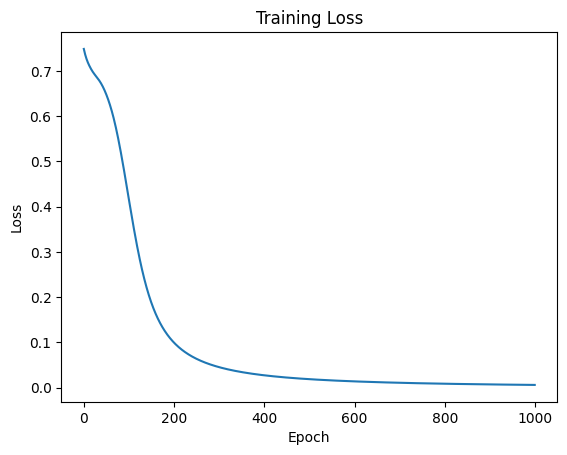

In [ ]:
plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

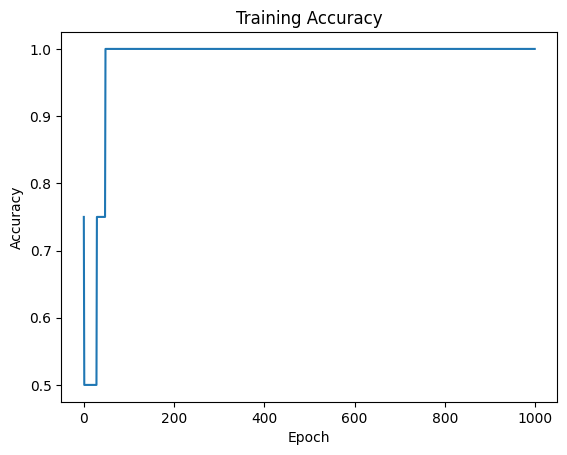

In [ ]:
plt.plot(history.history['accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.show()

Testing the XOR Model; predicting all 4 combinations

In [ ]:
predictions = model.predict(X)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
[[8.4899238e-04]
 [9.9725449e-01]
 [9.9004096e-01]
 [9.3208076e-03]]


In [ ]:
predicted_classes = (predictions >= 0.5).astype(int)

print(predicted_classes)

[[0]
 [1]
 [1]
 [0]]


Displaying the Results

In [ ]:
for i in range(len(X)):
    print(
        "Input:", X[i],
        "Actual:", int(y[i][0]),
        "Predicted:", int(predicted_classes[i][0])
    )

Input: [0. 0.] Actual: 0 Predicted: 0
Input: [0. 1.] Actual: 1 Predicted: 1
Input: [1. 0.] Actual: 1 Predicted: 1
Input: [1. 1.] Actual: 0 Predicted: 0


Experimenting With Hyperparameters

Experiment 1 - Learning Rate:

In [ ]:
learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:

    model = keras.Sequential([
        layers.Input(shape = (2,)),
        layers.Dense(4, activation = 'tanh'),
        layers.Dense(1, activation = 'sigmoid')
    ])

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=lr),
        loss = 'binary_crossentropy',
        metrics = ['accuracy']
    )

    history = model.fit(X, y, epochs = 1000, verbose = 0)

    print(
        "Learning Rate:",
        lr,
        "Final Accuracy:",
        history.history['accuracy'][-1],
        "Final Loss:",
        history.history['loss'][-1]
    )

Learning Rate: 0.001 Final Accuracy: 1.0 Final Loss: 0.31727972626686096
Learning Rate: 0.01 Final Accuracy: 1.0 Final Loss: 0.005352126434445381
Learning Rate: 0.1 Final Accuracy: 1.0 Final Loss: 0.00016643170965835452


Experiment 2 - Number of Hidden Neurons:

In [ ]:
neurons = [2, 4, 8, 16]

for n in neurons:

    model = keras.Sequential([
        layers.Input(shape = (2,)),
        layers.Dense(n, activation = 'tanh'),
        layers.Dense(1, activation = 'sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate = 0.01),
        loss = 'binary_crossentropy',
        metrics = ['accuracy']
    )

    history = model.fit(X, y, epochs = 1000, verbose = 0)

    print(
        "Neurons:",
        n,
        "Final Accuracy:",
        history.history['accuracy'][-1]
    )

Neurons: 2 Final Accuracy: 0.5
Neurons: 4 Final Accuracy: 1.0
Neurons: 8 Final Accuracy: 1.0
Neurons: 16 Final Accuracy: 1.0


Experiment 3 - Activation Function:

In [ ]:
activations = ['relu', 'tanh']

for activation in activations:

    model = keras.Sequential([
        layers.Input(shape = (2,)),
        layers.Dense(4, activation = activation),
        layers.Dense(1, activation = 'sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate = 0.01),
        loss = 'binary_crossentropy',
        metrics = ['accuracy']
    )

    history = model.fit(X, y, epochs = 1000, verbose = 0)

    print(
        "Activation:",
        activation,
        "Final Accuracy:",
        history.history['accuracy'][-1]
    )

Activation: relu Final Accuracy: 1.0
Activation: tanh Final Accuracy: 1.0


Experiment 4 - Number of Epochs:

In [ ]:
epochs_list = [10, 50, 100, 500, 1000]

for epochs in epochs_list:

    model = keras.Sequential([
        layers.Input(shape = (2,)),
        layers.Dense(4, activation = 'tanh'),
        layers.Dense(1, activation = 'sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate = 0.01),
        loss = 'binary_crossentropy',
        metrics = ['accuracy']
    )

    history = model.fit(
        X,
        y,
        epochs=epochs,
        verbose = 0
    )

    print(
        "Epochs:",
        epochs,
        "Final Accuracy:",
        history.history['accuracy'][-1]
    )

Epochs: 10 Final Accuracy: 0.5
Epochs: 50 Final Accuracy: 0.5
Epochs: 100 Final Accuracy: 1.0
Epochs: 500 Final Accuracy: 1.0
Epochs: 1000 Final Accuracy: 1.0


TensorFlow Low-Level Implementation

In [ ]:
X = tf.constant([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=tf.float32)

y = tf.constant([
    [0],
    [1],
    [1],
    [0]
], dtype=tf.float32)

Define the Network Parameters

In [ ]:
W1 = tf.Variable(
    tf.random.normal([2, 4]),
    trainable = True
)

b1 = tf.Variable(
    tf.zeros([4]),
    trainable = True
)

W2 = tf.Variable(
    tf.random.normal([4, 1]),
    trainable = True
)

b2 = tf.Variable(
    tf.zeros([1]),
    trainable = True
)

Defining the Forward Pass

In [ ]:
def forward_pass(X):
    Z1 = tf.matmul(X, W1) + b1
    A1 = tf.tanh(Z1)

    Z2 = tf.matmul(A1, W2) + b2
    A2 = tf.sigmoid(Z2)

    return A2

Defining the Loss Function

In [ ]:
def compute_loss(y_true, y_pred):
    return tf.reduce_mean(
        tf.keras.losses.binary_crossentropy(
            y_true,
            y_pred
        )
    )

Creating the Optimizer

In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate = 0.01
)

Training the Network Manually

In [ ]:
epochs = 1000

loss_history = []

for epoch in range(epochs):

    with tf.GradientTape() as tape:

        y_pred = forward_pass(X)

        loss = compute_loss(y, y_pred)

    gradients = tape.gradient(
        loss,
        [W1, b1, W2, b2]
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            [W1, b1, W2, b2]
        )
    )

    loss_history.append(loss.numpy())

    if (epoch + 1) % 100 == 0:
        print(
            "Epoch:",
            epoch + 1,
            "Loss:",
            loss.numpy()
        )

Epoch: 100 Loss: 0.30058816
Epoch: 200 Loss: 0.05399545
Epoch: 300 Loss: 0.022287903
Epoch: 400 Loss: 0.012861224
Epoch: 500 Loss: 0.00859159
Epoch: 600 Loss: 0.0062314006
Epoch: 700 Loss: 0.004764865
Epoch: 800 Loss: 0.0037803352
Epoch: 900 Loss: 0.0030819555
Epoch: 1000 Loss: 0.0025657127


In [ ]:
predictions = forward_pass(X)

print("Predictions:")
print(predictions.numpy())

Predictions:
[[0.00296687]
 [0.997352  ]
 [0.9974682 ]
 [0.00208493]]


In [ ]:
predicted_classes = (predictions.numpy() >= 0.5).astype(int)

print("Predicted Classes:")
print(predicted_classes)

Predicted Classes:
[[0]
 [1]
 [1]
 [0]]


In [ ]:
accuracy = np.mean(
    predicted_classes == y.numpy()
)

print("Accuracy:", accuracy * 100, "%")

Accuracy: 100.0 %


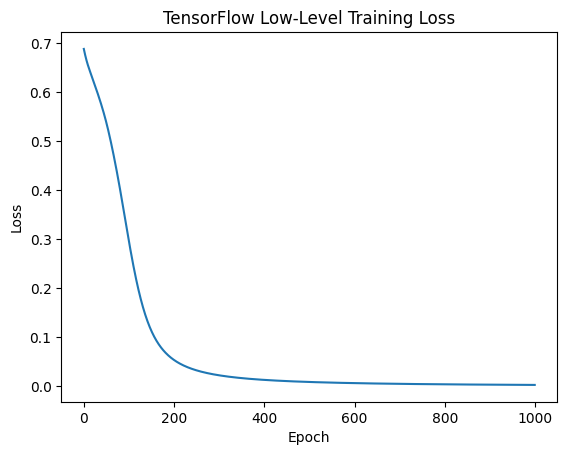

In [ ]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TensorFlow Low-Level Training Loss")
plt.show()